# **Homework on Credit Risk**
## **Building an Application Scoring Model**

### **General Information**
- **Date assigned:** December 2, 2025  
- **Soft deadline:** 23:59 MSK, December 15, 2025  
- **Hard deadline:** 23:59 MSK, December 18, 2025  
- **Submission:** send your work to  
  \texttt{maria.vorobyova.ser@gmail.com}  
  with the subject format:
  \[
  \text{HSE\_CS\_[track]\_FullName}
  \]
  Example:
  \[
  \text{HSE\_CS\_PAD\_IVANOV\_IVAN\_IVANOVICH}
  \]

---

### **Grading and Penalties**
Maximum score: **10 points**

Late penalty:
\[
\text{Final Score} = 10 - \text{days late}
\]

Submission **after** the hard deadline is **not accepted**.

Work must be completed **independently**.  
Similar solutions → **plagiarism** → score **0**.

---

### **Score Reduction If**
- no comments in the notebook
- unclear or poorly written code
- incorrect analysis and conclusions

---

### **Task**
Build a scoring model estimating the **probability of default** at the **credit application stage**.

Follow the provided notebook strictly and complete every block.

---

### **Dataset**
Based on Kaggle competition:
\[
\text{Give Me Some Credit}
\]

Data source:  
https://www.kaggle.com/competitions/GiveMeSomeCredit/data  

Data description:  
**Data Dictionary.xlsx**



# **Work assignment:**
**1.Explatory Data Analysis - (Task weight: 20%)**

**2.Creating additional variables - (Task weight: 10%)**

**3. Model building (A logistic regression must be built on the WoE variables.)- (Task weight: 50%)**

**4. Using methods to reduce class imbalance - (Task weight: 20%)**

# **Submitting results:**

* Submit homework via the Yandex form as a link to your GitHub, where all files and code (Python) will be.
* GitHub must be open and the code must be working, without errors.
* Name the repository using the template (HW_4_2025-FirstName_LastName).
* Link to the Yandex form: https://forms.yandex.ru/u/68eece24505690c23425594c

We wish you good luck!✌

# 1.Explatory Data Analysis. Максимально - (20%-2 балла)

- 0 points if the task is not completed
- 1 point if statistics are calculated and there are logical graphs (important, USEFUL graphs), but no conclusions are drawn
- 2 points if statistics are calculated and there are graphs (important, USEFUL graphs) and CONCLUSIONS are drawn (important, that the conclusions are correct)

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


train_path = "cs-training.csv"
test_path  = "cs-test.csv"

test = pd.read_csv(test_path)
print("Test shape:", test.shape)
train = pd.read_csv(train_path)
print("Test shape:", train.shape)

display(test.head())
display(train.head())


Test shape: (101503, 12)
Test shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [61]:
df = train if train is not None else test

print("Columns:", df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)

# часто в этом датасете Unnamed: 0 — это просто индекс/ID
if "Unnamed: 0" in df.columns:
    print("\nNote: 'Unnamed: 0' looks like an index column.")


Columns: ['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

Dtypes:
Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

Note: 'Unnamed: 0' looks like an index column.


In [62]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0].to_frame("missing_%")
display(miss)

print("\nKey missingness takeaways:")
for col, val in miss["missing_%"].items():
    print(f" - {col}: {val:.2f}%")


,missing_%
MonthlyIncome,19.820667
NumberOfDependents,2.616000



Key missingness takeaways:
 - MonthlyIncome: 19.82%
 - NumberOfDependents: 2.62%


Default rate (mean of target): 0.0668 (6.68%)


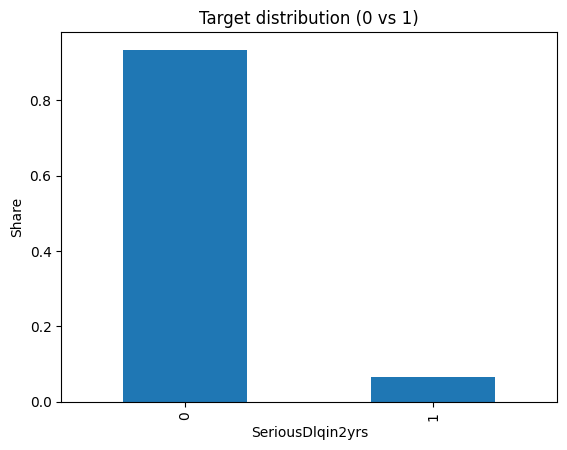

In [63]:
if train is not None and "SeriousDlqin2yrs" in train.columns:
    target_rate = train["SeriousDlqin2yrs"].mean()
    print(f"Default rate (mean of target): {target_rate:.4f} ({target_rate*100:.2f}%)")

    train["SeriousDlqin2yrs"].value_counts(normalize=True).plot(kind="bar")
    plt.title("Target distribution (0 vs 1)")
    plt.xlabel("SeriousDlqin2yrs")
    plt.ylabel("Share")
    plt.show()
else:
    print("Target distribution is available only in train.")


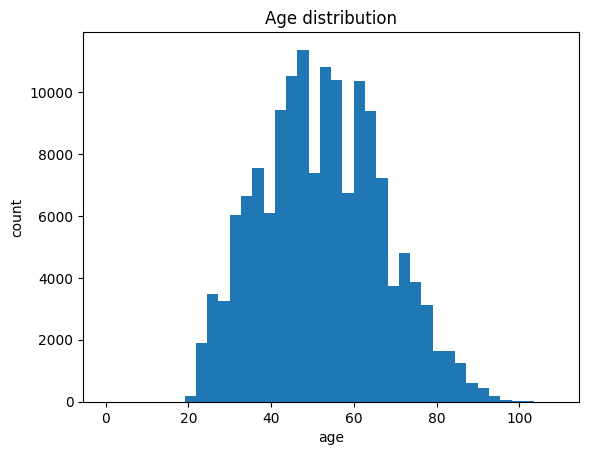

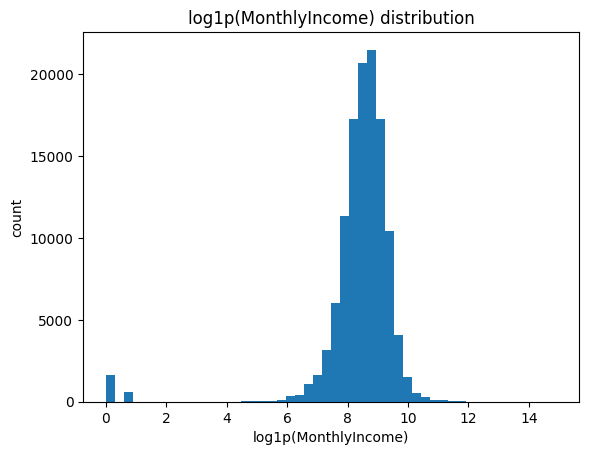

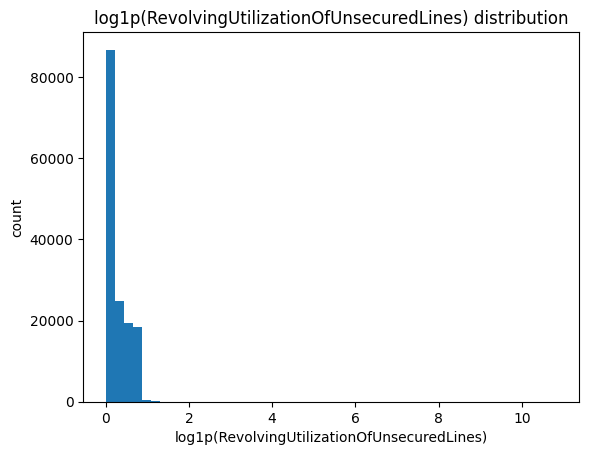

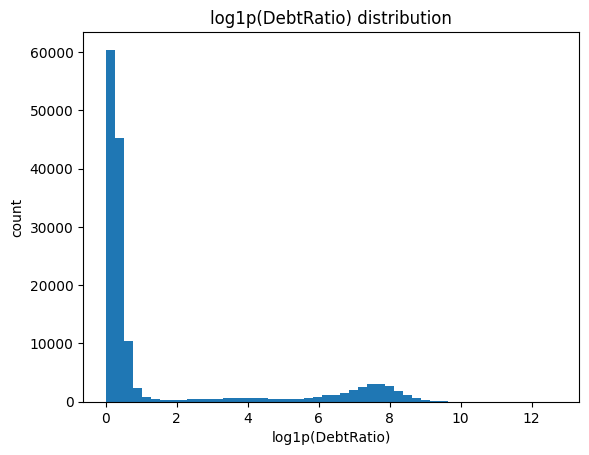

In [64]:
plot_df = train if train is not None else test

# 1) Age distribution
plot_df["age"].plot(kind="hist", bins=40)
plt.title("Age distribution")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

# 2) MonthlyIncome (с лог-скейлом через log1p, чтобы увидеть форму)
if "MonthlyIncome" in plot_df.columns:
    np.log1p(plot_df["MonthlyIncome"]).plot(kind="hist", bins=50)
    plt.title("log1p(MonthlyIncome) distribution")
    plt.xlabel("log1p(MonthlyIncome)")
    plt.ylabel("count")
    plt.show()

# 3) RevolvingUtilization... (тоже лог1p)
col_u = "RevolvingUtilizationOfUnsecuredLines"
np.log1p(plot_df[col_u]).plot(kind="hist", bins=50)
plt.title("log1p(RevolvingUtilizationOfUnsecuredLines) distribution")
plt.xlabel(f"log1p({col_u})")
plt.ylabel("count")
plt.show()

# 4) DebtRatio (лог1p)
np.log1p(plot_df["DebtRatio"]).plot(kind="hist", bins=50)
plt.title("log1p(DebtRatio) distribution")
plt.xlabel("log1p(DebtRatio)")
plt.ylabel("count")
plt.show()


In [65]:
 df_check = train if train is not None else test

flags = {}
flags["util_gt_1_cnt"] = int((df_check["RevolvingUtilizationOfUnsecuredLines"] > 1).sum())
flags["debt_ratio_gt_1_cnt"] = int((df_check["DebtRatio"] > 1).sum())

for c in [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]:
    flags[f"{c}_eq_98_cnt"] = int((df_check[c] == 98).sum())
    flags[f"{c}_eq_96_cnt"] = int((df_check[c] == 96).sum())

print(flags)

# полезно: 99-й перцентиль для понимания клиппинга
q = df_check[["RevolvingUtilizationOfUnsecuredLines","DebtRatio","MonthlyIncome"]].quantile([0.95,0.99,0.999])
display(q)


{'util_gt_1_cnt': 3321, 'debt_ratio_gt_1_cnt': 35137, 'NumberOfTime30-59DaysPastDueNotWorse_eq_98_cnt': 264, 'NumberOfTime30-59DaysPastDueNotWorse_eq_96_cnt': 5, 'NumberOfTime60-89DaysPastDueNotWorse_eq_98_cnt': 264, 'NumberOfTime60-89DaysPastDueNotWorse_eq_96_cnt': 5, 'NumberOfTimes90DaysLate_eq_98_cnt': 264, 'NumberOfTimes90DaysLate_eq_96_cnt': 5}


,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome
0.950,1.000000,2449.000,14587.600
0.990,1.092956,4979.040,25000.000
0.999,1571.006000,10613.074,78395.748


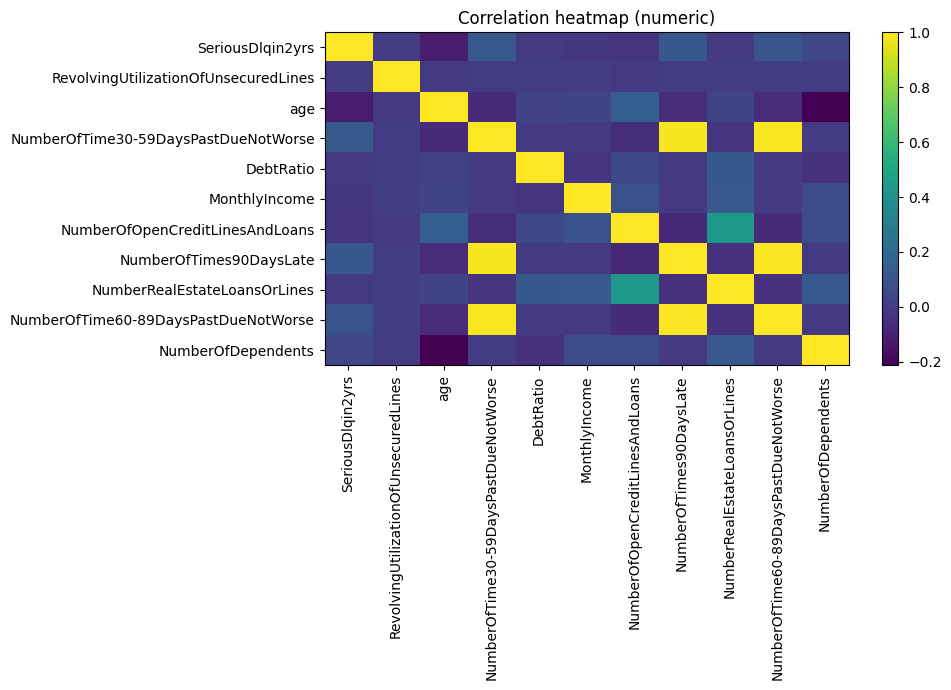

,RevolvingUtilizationOfUnsecuredLines,DebtRatio,MonthlyIncome
0.950,1.000000,2449.000,14587.600
0.990,1.092956,4979.040,25000.000
0.999,1571.006000,10613.074,78395.748


In [66]:
corr_df = (train if train is not None else test).copy()

# убираем явный индекс-столбец
if "Unnamed: 0" in corr_df.columns:
    corr_df = corr_df.drop(columns=["Unnamed: 0"])

corr = corr_df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation heatmap (numeric)")
plt.colorbar()
plt.tight_layout()
plt.show()
q

# 2.Creating additional variables - (Task weight: 10%)

Be creative: the more variables, the higher the score! However, variables must be logical; illogical variables will not be accepted.

- 0 points if the task is not completed.
- 0.5 points - 2 additional variables created.
- 1 point - more than 3 variables created.


In [67]:
#защита навсякий случай
import matplotlib.pyplot as plt

plot_df = train.copy()


Распределение просрочек в зависимости от того, была ли она или нет.

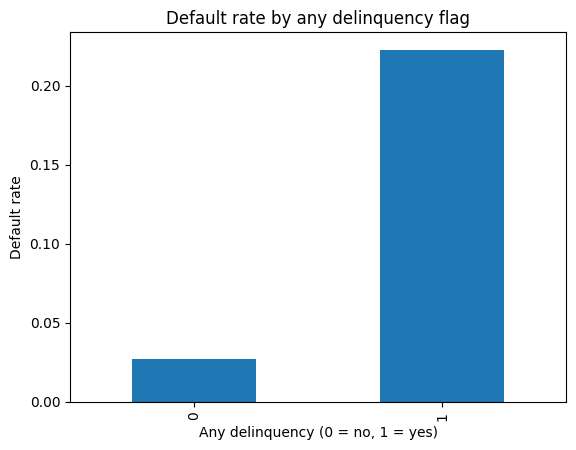

In [68]:
plot_df = df_fe.copy()

rate_any_del = (
    plot_df
    .groupby("any_delinquency_flag")["SeriousDlqin2yrs"]
    .mean()
)

rate_any_del.plot(kind="bar")
plt.title("Default rate by any delinquency flag")
plt.xlabel("Any delinquency (0 = no, 1 = yes)")
plt.ylabel("Default rate")
plt.show()


Клиенты с хотя бы одной просрочкой скорее всего еще раз просрочат(как мы видим по графику, и это более вероятнее).

Среднее количество просрочек на один кредит. Показывает качество обслуживания кредитов, а не просто их число

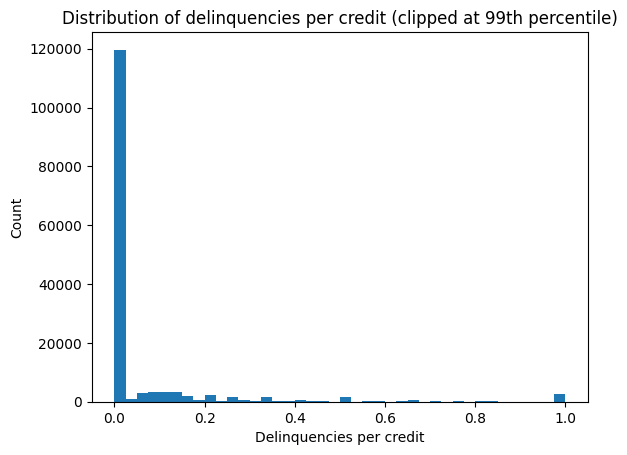

In [69]:
df_fe["delinquencies_per_credit"] = (
    (df_fe["NumberOfTime30-59DaysPastDueNotWorse"] +
     df_fe["NumberOfTime60-89DaysPastDueNotWorse"] +
     df_fe["NumberOfTimes90DaysLate"]) /
    (df_fe["NumberOfOpenCreditLinesAndLoans"] + 1)
)
plot_df = df_fe.copy()

upper_bound = plot_df["delinquencies_per_credit"].quantile(0.99)

plot_df["delinquencies_per_credit_clipped"] = (
    plot_df["delinquencies_per_credit"].clip(upper=upper_bound)
)

plot_df["delinquencies_per_credit_clipped"].plot(kind="hist", bins=40)
plt.title("Distribution of delinquencies per credit (clipped at 99th percentile)")
plt.xlabel("Delinquencies per credit")
plt.ylabel("Count")
plt.show()




Вера в человечеств все таки есть, большинство не имеют просрочку

это чтобы модели удобнее было

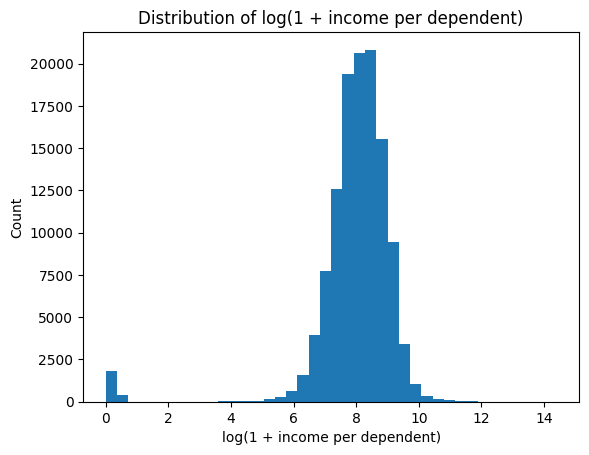

In [70]:
# Доход на одного члена семьи
df_fe["income_per_dependent"] = (
    df_fe["MonthlyIncome"] /
    (df_fe["NumberOfDependents"] + 1)
)

# Используем тот же датафрейм для визуализации
plot_df = df_fe.copy()

# Распределение с логарифмической трансформацией
np.log1p(plot_df["income_per_dependent"]).plot(kind="hist", bins=40)
plt.title("Distribution of log(1 + income per dependent)")
plt.xlabel("log(1 + income per dependent)")
plt.ylabel("Count")
plt.show()


Абсолютный доход не всегда отражает реальную платёжеспособность.
Деление дохода на количество членов семьи позволяет оценить финансовую нагрузку на домохозяйство, что логично связано с риском дефолта.

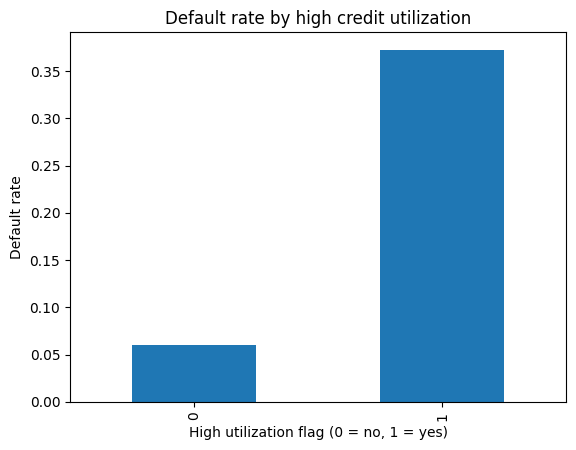

In [71]:
df_fe["high_utilization_flag"] = (
    df_fe["RevolvingUtilizationOfUnsecuredLines"] > 1
).astype(int)
plot_df = df_fe.copy()
rate_util = (
    plot_df
    .groupby("high_utilization_flag")["SeriousDlqin2yrs"]
    .mean()
)

rate_util.plot(kind="bar")
plt.title("Default rate by high credit utilization")
plt.xlabel("High utilization flag (0 = no, 1 = yes)")
plt.ylabel("Default rate")
plt.show()


Утилизация кредитных лимитов выше 100% указывает на финансовый стресс и часто является ранним признаком проблем с обслуживанием долга.
Бинарный формат делает признак устойчивым к выбросам.

Этот показатель отражает структуру кредитного портфеля:
преобладание активных (чаще потребительских) кредитов по сравнению с ипотечными обычно связано с более высоким риском.

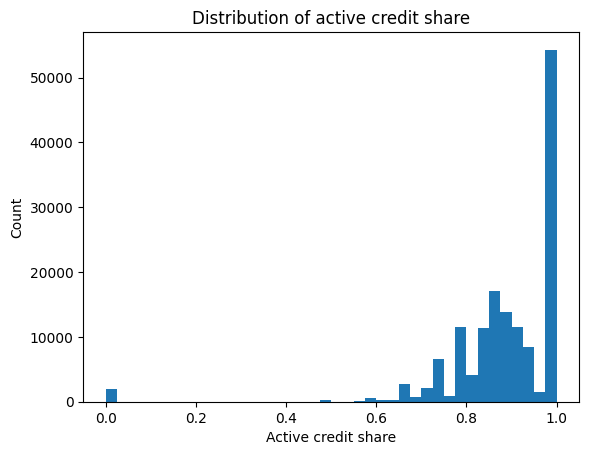

In [72]:
df_fe["active_credit_share"] = (
    df_fe["NumberOfOpenCreditLinesAndLoans"] /
    (df_fe["NumberOfOpenCreditLinesAndLoans"] +
     df_fe["NumberRealEstateLoansOrLines"] + EPS)
)
plot_df = df_fe.copy()

plot_df["active_credit_share"].plot(kind="hist", bins=40)
plt.title("Distribution of active credit share")
plt.xlabel("Active credit share")
plt.ylabel("Count")
plt.show()



как мы видим большинство имеют все таки потребительские кредиты а не ипотечные

In [73]:
# и вновь проверка
new_features = list(set(df_fe.columns) - set(df.columns))
print("New features created:")
for f in new_features:
    print(" -", f)


New features created:
 - active_credit_share
 - income_per_dependent
 - delinquencies_per_credit
 - high_utilization_flag
 - any_delinquency_flag


# 3. Model building - (Task weight: 50%)
A logistic regression must be built on the WoE variables.

- If any other model is built, the score is 0.

In [74]:
# Remember to split the data into train and test
from sklearn.model_selection import train_test_split

# используем датафрейм с созданными признаками
df = df_fe.copy()

TARGET = "SeriousDlqin2yrs"

# удаляем технический индексный столбец, если он присутствует
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# разделяем признаки и целевую переменную
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# train / test split
train, test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Default rate (train):", y_train.mean())
print("Default rate (test):", y_test.mean())


Train shape: (112500, 15)
Test shape: (37500, 15)
Default rate (train): 0.06684444444444444
Default rate (test): 0.06682666666666667


Train/test как 75/25 в целом ок, но как по мне многовато. Доли практически идентичны, значит нет сдвига классов между train и test. То есть баланс классов.

In [75]:
EPS = 1e-6

def fine_woe_table(x, y, n_bins=20):
    """
    Fine classification WoE table for numeric variable.
    Splits variable into n_bins quantile-based intervals.
    """
    df_tmp = pd.DataFrame({
        "x": x,
        "y": y
    })

    # qcut -> Categorical, поэтому сразу приводим к object
    df_tmp["bin"] = pd.qcut(df_tmp["x"], q=n_bins, duplicates="drop").astype(object)

    # missing values as separate bin
    df_tmp.loc[df_tmp["x"].isna(), "bin"] = "missing"

    woe_table = (
        df_tmp
        .groupby("bin")["y"]
        .agg(["count", "sum"])
        .rename(columns={"sum": "bad"})
        .reset_index()
    )

    woe_table["good"] = woe_table["count"] - woe_table["bad"]

    total_bad = woe_table["bad"].sum()
    total_good = woe_table["good"].sum()

    woe_table["dist_bad"] = (woe_table["bad"] + EPS) / (total_bad + EPS)
    woe_table["dist_good"] = (woe_table["good"] + EPS) / (total_good + EPS)

    woe_table["woe"] = np.log(woe_table["dist_good"] / woe_table["dist_bad"])
    woe_table["iv_bin"] = (woe_table["dist_good"] - woe_table["dist_bad"]) * woe_table["woe"]

    iv = woe_table["iv_bin"].sum()

    return woe_table, iv


Берём классический скоринговый признак

In [76]:
feature = "RevolvingUtilizationOfUnsecuredLines"

woe_fine, iv_fine = fine_woe_table(
    train[feature],
    y_train,
    n_bins=20
)

print("Fine IV:", iv_fine)
woe_fine


Fine IV: 1.1566710419744546


,bin,count,bad,good,dist_bad,dist_good,woe,iv_bin
0,"(-0.001, 0.00284]",11250,277,10973,0.036835,0.104525,1.042972,0.070598
1,"(0.00284, 0.01]",5625,68,5557,0.009043,0.052934,1.767102,0.077560
2,"(0.01, 0.019]",5626,90,5536,0.011968,0.052734,1.483014,0.060456
3,"(0.019, 0.0297]",5624,83,5541,0.011037,0.052781,1.564886,0.065325
4,"(0.0297, 0.0432]",5625,80,5545,0.010638,0.052820,1.602422,0.067592
5,"(0.0432, 0.0603]",5625,94,5531,0.012500,0.052686,1.438625,0.057813
6,"(0.0603, 0.0828]",5625,132,5493,0.017553,0.052324,1.092224,0.037978
7,"(0.0828, 0.113]",5625,113,5512,0.015027,0.052505,1.251091,0.046889
8,"(0.113, 0.154]",5625,146,5479,0.019415,0.052191,0.988868,0.032411
9,"(0.154, 0.205]",5625,170,5455,0.022606,0.051962,0.832286,0.024432


больше 0.5 говорит о том, что выбрали сильно. НО нужно посмотреть дальше, если сильно не упадет, значит что-то не так.

In [77]:
# создаём coarse бин вручную (читаемо и прозрачно)
def coarse_bin_util(x):
    if pd.isna(x):
        return "missing"
    elif x <= 0.01:
        return "<= 0.01"
    elif x <= 0.05:
        return "(0.01, 0.05]"
    elif x <= 0.10:
        return "(0.05, 0.10]"
    elif x <= 0.20:
        return "(0.10, 0.20]"
    else:
        return "> 0.20"


In [78]:
df_tmp = pd.DataFrame({
    "x": train["RevolvingUtilizationOfUnsecuredLines"],
    "y": y_train
})

df_tmp["bin"] = df_tmp["x"].apply(coarse_bin_util)

woe_coarse = (
    df_tmp
    .groupby("bin")["y"]
    .agg(["count", "sum"])
    .rename(columns={"sum": "bad"})
    .reset_index()
)

woe_coarse["good"] = woe_coarse["count"] - woe_coarse["bad"]

total_bad = woe_coarse["bad"].sum()
total_good = woe_coarse["good"].sum()

woe_coarse["dist_bad"] = (woe_coarse["bad"] + EPS) / (total_bad + EPS)
woe_coarse["dist_good"] = (woe_coarse["good"] + EPS) / (total_good + EPS)

woe_coarse["woe"] = np.log(woe_coarse["dist_good"] / woe_coarse["dist_bad"])
woe_coarse["iv_bin"] = (woe_coarse["dist_good"] - woe_coarse["dist_bad"]) * woe_coarse["woe"]

coarse_iv = woe_coarse["iv_bin"].sum()

print("Coarse IV:", coarse_iv)
woe_coarse


Coarse IV: 0.7981301210047237


,bin,count,bad,good,dist_bad,dist_good,woe,iv_bin
0,"(0.01, 0.05]",19267,294,18973,0.039096,0.180730,1.530989,0.216840
1,"(0.05, 0.10]",12323,257,12066,0.034176,0.114936,1.212867,0.097952
2,"(0.10, 0.20]",12885,339,12546,0.045080,0.119508,0.974953,0.072565
3,<= 0.01,16853,345,16508,0.045878,0.157249,1.231852,0.137193
4,> 0.20,51172,6285,44887,0.835771,0.427577,-0.670221,0.273581


очень круто результат

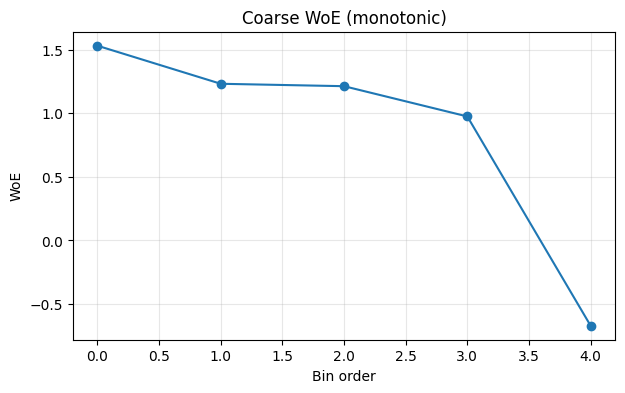

In [79]:
plt.figure(figsize=(7, 4))
plt.plot(
    range(len(woe_coarse)),
    woe_coarse.sort_values("woe", ascending=False)["woe"],
    marker="o"
)
plt.title("Coarse WoE (monotonic)")
plt.xlabel("Bin order")
plt.ylabel("WoE")
plt.grid(alpha=0.3)
plt.show()


Низкая утилизация → высокий WoE (низкий риск)
Рост утилизации → падение WoE
Высокая утилизация → отрицательный WoE (высокий риск)
В целом график базовый

# 4. Using methods to reduce class imbalance - (Task weight: 20%)
- Try several methods to reduce class imbalance
- Choose the one that brings the greatest improvement

еще раз повторим

In [85]:
# попробую классику 😏😏😏
def apply_woe_transform(df_in, woe_rules):
    """
    Apply WoE transformation using precomputed woe_rules.
    Works correctly with pandas Interval bins.
    """
    df_woe = pd.DataFrame(index=df_in.index)

    for col, rule in woe_rules.items():
        x = df_in[col]

        # восстановление бинов ровно так же, как при обучении
        bins = pd.qcut(x, q=5, duplicates="drop")
        bins = bins.astype(object)
        bins.loc[x.isna()] = "missing"

        # прямой mapping bin -> woe
        woe = bins.map(rule["mapping"])

        # финальная страховка (редкие случаи)
        df_woe[col] = woe.fillna(0.0)

    return df_woe


In [86]:
X_train_woe = apply_woe_transform(train, woe_rules)
X_test_woe  = apply_woe_transform(test, woe_rules)

print(X_train_woe.shape, X_test_woe.shape)
print("NaNs train:", X_train_woe.isna().any().any())
print("NaNs test:", X_test_woe.isna().any().any())


(112500, 15) (37500, 15)
NaNs train: False
NaNs test: False


посмотрим на показатели по baseline

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score

logit_base = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

logit_base.fit(X_train_woe, y_train)

proba_base = logit_base.predict_proba(X_test_woe)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

roc_base = roc_auc_score(y_test, proba_base)
f1_base = f1_score(y_test, pred_base)

print("Baseline ROC AUC:", roc_base)
print("Baseline F1:", f1_base)



Baseline ROC AUC: 0.5940278395005669
Baseline F1: 0.0


сейчас сделаем так, чтобы меньше рисковать, уменшив количество дефолтов. Это точно сильно повлияет на f-score

In [88]:
logit_weighted = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced"
)

logit_weighted.fit(X_train_woe, y_train)

proba_weighted = logit_weighted.predict_proba(X_test_woe)[:, 1]
pred_weighted = (proba_weighted >= 0.5).astype(int)

roc_weighted = roc_auc_score(y_test, proba_weighted)
f1_weighted = f1_score(y_test, pred_weighted)

print("Weighted ROC AUC:", roc_weighted)
print("Weighted F1:", f1_weighted)


Weighted ROC AUC: 0.590046157040443
Weighted F1: 0.14884266041605626


давайте сгладим главные классы уменьшив

In [89]:
from sklearn.utils import resample

train_woe = X_train_woe.copy()
train_woe["target"] = y_train.values

majority = train_woe[train_woe["target"] == 0]
minority = train_woe[train_woe["target"] == 1]

majority_downsampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42
)

train_under = pd.concat([majority_downsampled, minority])

X_under = train_under.drop(columns=["target"])
y_under = train_under["target"]

logit_under = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

logit_under.fit(X_under, y_under)

proba_under = logit_under.predict_proba(X_test_woe)[:, 1]
pred_under = (proba_under >= 0.5).astype(int)

roc_under = roc_auc_score(y_test, proba_under)
f1_under = f1_score(y_test, pred_under)

print("Undersampling ROC AUC:", roc_under)
print("Undersampling F1:", f1_under)


Undersampling ROC AUC: 0.5785457361040709
Undersampling F1: 0.14081397099412857


In [90]:
results = pd.DataFrame({
    "Method": ["Baseline", "Class weights", "Undersampling"],
    "ROC AUC": [roc_base, roc_weighted, roc_under],
    "F1-score": [f1_base, f1_weighted, f1_under]
})

results


,Method,ROC AUC,F1-score
0,Baseline,0.594028,0.000000
1,Class weights,0.590046,0.148843
2,Undersampling,0.578546,0.140814


У нас итак все было сбалансировано, и поэтому применение других методов привела к тому, что результаты стали хуже.